In [7]:
!pip install yfinance matplotlib seaborn


Original Data:
                               Open      High       Low     Close     Volume  \
Date                                                                           
2010-06-29 00:00:00-04:00  1.266667  1.666667  1.169333  1.592667  281494500   
2010-06-30 00:00:00-04:00  1.719333  2.028000  1.553333  1.588667  257806500   
2010-07-01 00:00:00-04:00  1.666667  1.728000  1.351333  1.464000  123282000   
2010-07-02 00:00:00-04:00  1.533333  1.540000  1.247333  1.280000   77097000   
2010-07-06 00:00:00-04:00  1.333333  1.333333  1.055333  1.074000  103003500   

                           Dividends  Stock Splits  
Date                                                
2010-06-29 00:00:00-04:00        0.0           0.0  
2010-06-30 00:00:00-04:00        0.0           0.0  
2010-07-01 00:00:00-04:00        0.0           0.0  
2010-07-02 00:00:00-04:00        0.0           0.0  
2010-07-06 00:00:00-04:00        0.0           0.0  

Missing Values Before Cleaning:
Open            0
Hi

<ipython-input-9-93c9c5f8205d>:26: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


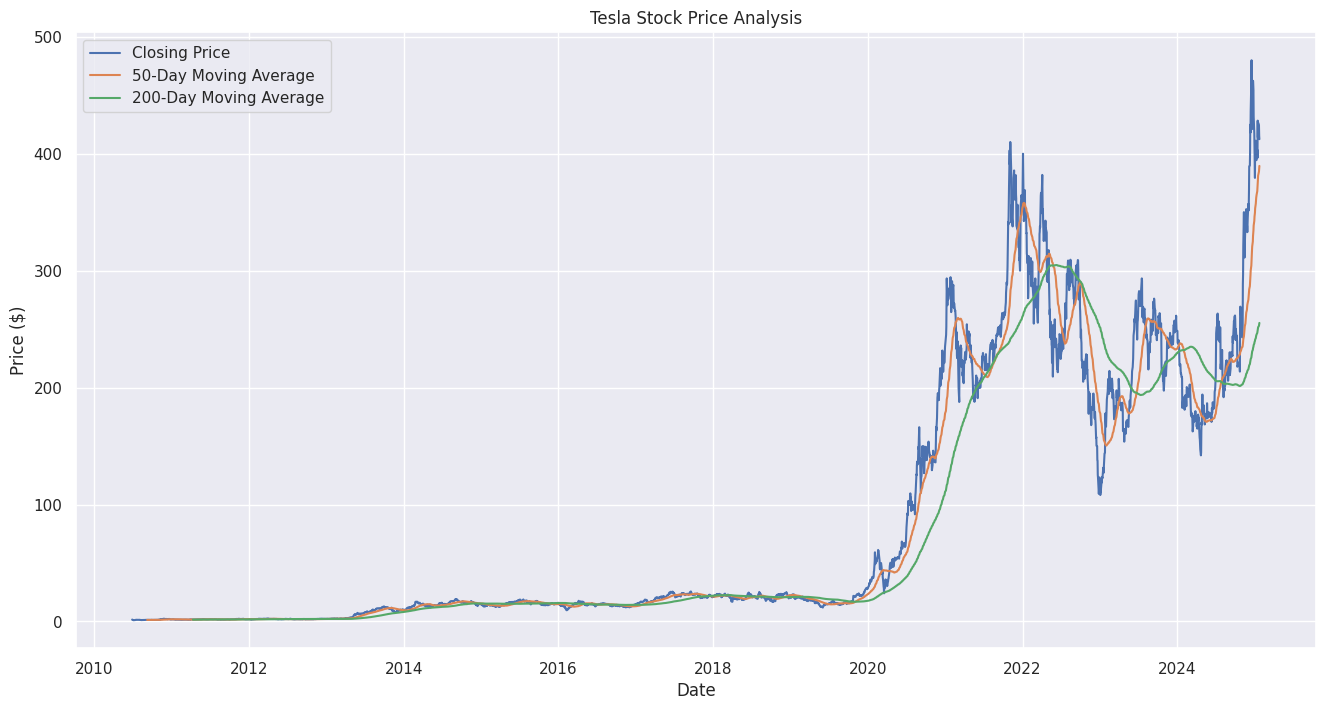

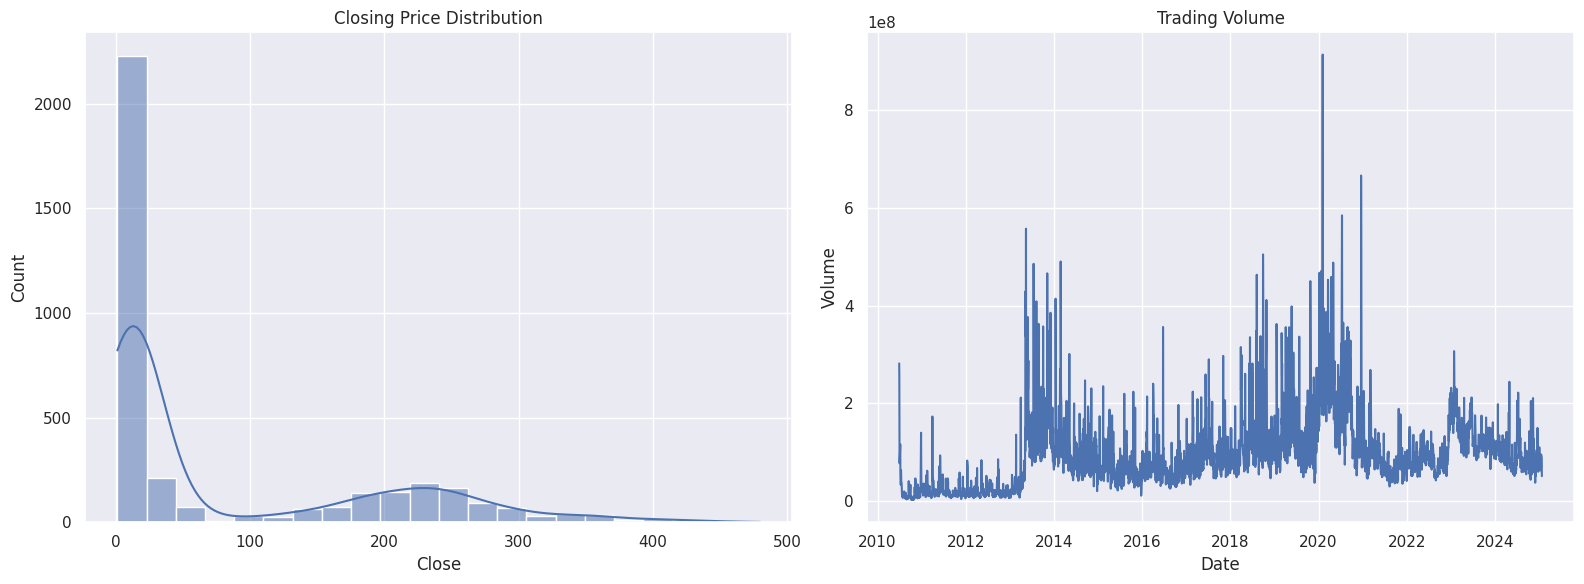

In [9]:
!pip install yfinance

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

tesla = yf.Ticker("TSLA")
df = tesla.history(period="max")

print("Original Data:")
print(df.head())

print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

df.fillna(method='ffill', inplace=True)

print("\nNumber of Duplicates:", df.index.duplicated().sum())

df = df[~df.index.duplicated(keep='first')]

print("\nInvalid Data (Negative Prices):")
print(df[(df['Open'] < 0) | (df['Close'] < 0) | (df['High'] < 0) | (df['Low'] < 0)])

df['50_MA'] = df['Close'].rolling(window=50).mean()
df['200_MA'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(16, 8))
plt.title('Tesla Stock Price Analysis')
plt.plot(df['Close'], label='Closing Price')
plt.plot(df['50_MA'], label='50-Day Moving Average')
plt.plot(df['200_MA'], label='200-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['Close'], kde=True)
plt.title('Closing Price Distribution')

plt.subplot(1, 2, 2)
plt.plot(df['Volume'])
plt.title('Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.tight_layout()
plt.show()